In [1]:
!pip install --upgrade scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 3.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.1
    Uninstalling scipy-1.11.1:
      Successfully uninstalled scipy-1.11.1


# EXPLORATORY DATA ANALYSIS 2

## Let's play with dissimilarity measures

### Numerical attributes

In [10]:
from scipy.spatial.distance import minkowski,euclidean,chebyshev

#manhattan distance
print(minkowski([1, 0, 0], [0, 1, 0],1))

#euclidean distance
print(euclidean([1, 0, 0], [0, 1, 0]))

#5-minkowski distance
print(minkowski([1, 0, 0], [0, 1, 0],5))

#chebyshev distance
print(chebyshev([1, 0, 0], [0, 1, 0]))
print(minkowski([1, 0, 0], [0, 1, 0],200)) ## increasing the power we should get the same result as the chebyshev distance



2.0
1.4142135623730951
1.148698354997035
1
1.0034717485095028


### Nominal attibutes

In [11]:
## nominal attributes
def nominal_distance(x, y):
    p = len(x)
    m = sum(1 if a == b else 0 for a, b in zip(x, y))
    return float(p - m) / p

nominal_distance(['green','blue','yellow'], ['red', 'blue', 'yellow'])

0.3333333333333333

### Binary attributes

In [12]:
v1=[1,0,1,0,0,1,0]
v2=[1,0,1,0,0,0,1]

import numpy as np
def symmetric_binary_distance(arr1, arr2):
    """
    Compute the symmetric binary distance between two binary arrays.

    Parameters:
        arr1 (array-like): The first binary array.
        arr2 (array-like): The second binary array.

    Returns:
        float: The symmetric binary distance.
    """
    # Compute the contingency table
    ct = [[0, 0], [0, 0]]
    for a, b in zip(arr1, arr2):
        ct[a][b] += 1

    # Compute the symmetric binary distance
    numerator = ct[0][1] + ct[1][0]
    denominator = sum(sum(row) for row in ct)
    distance = numerator / denominator

    return distance

#symmetric binary distance
print(symmetric_binary_distance(v1,v2))

#asymmetric binary distance
from scipy.spatial.distance import jaccard
print(jaccard(v1,v2))

0.2857142857142857
0.5


### Ordinal attributes

In [13]:
import pandas as pd

def ordinal_to_numeric(df, mappings):
    """
    Convert ordinal string values in a DataFrame to numerical ordered values and rescale between 0 and 1 based on the number of different values in the mappings.

    Parameters:
        df (DataFrame): The pandas DataFrame containing ordinal string values.
        mappings (dict): A dictionary where keys are column names and values are dictionaries mapping ordinal string values to numerical ordered values.

    Returns:
        DataFrame: A new DataFrame with ordinal string values replaced by rescaled numerical ordered values.
    """
    # Create a copy of the DataFrame to avoid modifying the original DataFrame
    df_copy = df.copy()

    # Map ordinal string values to numerical ordered values for each column
    for col, mapping in mappings.items():
        if col in df_copy.columns:
            df_copy[col] = pd.to_numeric(df_copy[col].map(mapping))
            # Rescale the numerical values between 0 and 1
            num_values = len(mapping)
            df_copy[col] = df_copy[col] / (num_values - 1)  # Rescale between 0 and 1

    return df_copy

In [37]:
data = {
    'Temperature': ['Low', 'High', 'Medium', 'Low', 'Medium'],
    'Humidity': ['Medium', 'Low', 'High', 'Low', 'Medium'],
    'Wind': ['Low', 'Absent', 'Low', 'High', 'Medium']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df


,Temperature,Humidity,Wind
0,Low,Medium,Low
1,High,Low,Absent
2,Medium,High,Low
3,Low,Low,High
4,Medium,Medium,Medium


In [14]:


### Define the maps to be used in string to rank transition
map_3={'Low':0,
        'Medium':1,
        'High':2}

map_4={'Absent':0,
        'Low':1,
        'Medium':2,
        'High':3}

mappings = {'Temperature': map_3, 'Humidity': map_3, 'Wind': map_4}

# Convert ordinal string values to numerical ordered values
numeric_df = ordinal_to_numeric(df, mappings)

# Display the DataFrame with numerical ordered values
numeric_df

,Survived,Pclass,Sex,Age_Group,SibSp,Parch,Fare,Embarked
0,0,3,male,Young,1,0,7.2500,S
1,1,1,female,Middle,1,0,71.2833,C
2,1,3,female,Middle,0,0,7.9250,S
3,1,1,female,Middle,1,0,53.1000,S
4,0,3,male,Middle,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,Middle,0,0,13.0000,S
887,1,1,female,Young,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,Middle,0,0,30.0000,C


In [15]:
from scipy.spatial.distance import euclidean
## to compute dissimilarity between, e.g., record 0 and 3, we can now
## use the distance measures defined for purely numerical attributes
euclidean(numeric_df.loc[0,:].values, numeric_df.loc[3,:].values)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

### Cosine distance

In [16]:
from scipy.spatial.distance import cosine

v1=[1,0,1,0,0,1,0]
v2=[1,0,1,0,0,0,1]

print(f"Cosine distance: {cosine(v1, v2)}")
print(f"Cosine similarity: {1-cosine(v1, v2)}")


Cosine distance: 0.33333333333333337
Cosine similarity: 0.6666666666666666


In [17]:
# It is insensitive to multiplicative factors
1-cosine(v1, 3*np.array(v2))

np.float64(0.6666666666666666)

In [18]:
# It is insensitive to multiplicative factors
1-cosine(v1, 2*np.array(v1))

np.float64(1.0)

### Text similarity via TF-IDF

In [19]:


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


documents = [
    "Machine learning models are widely used in data science. A machine learning model can learn patterns from data and make predictions.",

    "Deep learning models are a class of machine learning algorithms. Deep neural networks are widely used for image recognition and speech processing.",

    "Data science combines statistics, machine learning, and data visualization. Modern data science pipelines process large volumes of information.",

    "New York is a large city in the United States. New York has many financial institutions and technology companies.",

    "Credit card fraud detection is a common application of machine learning. Fraud detection systems analyze transaction data to detect suspicious activity.",

    "Travelers visiting New York often explore museums, parks, and restaurants. Tourism plays an important role in the economy of New York City."
]

# --------------------------------------------------
# A) Word TF-IDF only (unigrams)
# --------------------------------------------------

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 1),   # only unigrams
    lowercase=True
)

X_word = word_vectorizer.fit_transform(documents)

print("=== Word vocabulary ===")
print(word_vectorizer.get_feature_names_out())
print("\nShape of encoded documents:", X_word.shape)

# Cosine similarity between documents
sim_word = cosine_similarity(X_word)
print("\n=== Cosine similarity between encodings ===")
print(sim_word)


# --------------------------------------------------
# Example: inspect TF-IDF weights for one document
# --------------------------------------------------
doc_index = 0
feature_names = word_vectorizer.get_feature_names_out()
row = X_word[doc_index].toarray().ravel()
 
weights_sorted = sorted([(feature_names[i], r) for i, r in enumerate(row)], key=lambda x: x[1], reverse=True)

print(f"\n=== Nonzero TF-IDF features for document {doc_index} ===")
for term, weight in weights_sorted:
    print(f"{term:25s} {weight:.4f}")

=== Word vocabulary ===
['activity' 'algorithms' 'an' 'analyze' 'and' 'application' 'are' 'can'
 'card' 'city' 'class' 'combines' 'common' 'companies' 'credit' 'data'
 'deep' 'detect' 'detection' 'economy' 'explore' 'financial' 'for' 'fraud'
 'from' 'has' 'image' 'important' 'in' 'information' 'institutions' 'is'
 'large' 'learn' 'learning' 'machine' 'make' 'many' 'model' 'models'
 'modern' 'museums' 'networks' 'neural' 'new' 'of' 'often' 'parks'
 'patterns' 'pipelines' 'plays' 'predictions' 'process' 'processing'
 'recognition' 'restaurants' 'role' 'science' 'speech' 'states'
 'statistics' 'suspicious' 'systems' 'technology' 'the' 'to' 'tourism'
 'transaction' 'travelers' 'united' 'used' 'visiting' 'visualization'
 'volumes' 'widely' 'york']

Shape of encoded documents: (6, 76)

=== Cosine similarity between encodings ===
[[1.         0.32166743 0.35908859 0.04546159 0.12912584 0.04085266]
 [0.32166743 1.         0.09041729 0.0142858  0.06821951 0.03005123]
 [0.35908859 0.09041729 1. 

In [20]:

# --------------------------------------------------
# B) Mixed n-gram TF-IDF (unigrams + bigrams)
# --------------------------------------------------
ngram_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),   # unigrams + bigrams
    lowercase=True
)

X_ngram = ngram_vectorizer.fit_transform(documents)

print("\n=== Word + Bigram vocabulary ===")
print(ngram_vectorizer.get_feature_names_out())
print("\nShape of encoded documents:", X_ngram.shape)

sim_ngram = cosine_similarity(X_ngram)
print("\n=== Cosine similarity (word + bigram) ===")
print(sim_ngram)




=== Word + Bigram vocabulary ===
['activity' 'algorithms' 'algorithms deep' 'an' 'an important' 'analyze'
 'analyze transaction' 'and' 'and data' 'and make' 'and restaurants'
 'and speech' 'and technology' 'application' 'application of' 'are'
 'are class' 'are widely' 'can' 'can learn' 'card' 'card fraud' 'city'
 'city in' 'class' 'class of' 'combines' 'combines statistics' 'common'
 'common application' 'companies' 'credit' 'credit card' 'data' 'data and'
 'data science' 'data to' 'data visualization' 'deep' 'deep learning'
 'deep neural' 'detect' 'detect suspicious' 'detection' 'detection is'
 'detection systems' 'economy' 'economy of' 'explore' 'explore museums'
 'financial' 'financial institutions' 'for' 'for image' 'fraud'
 'fraud detection' 'from' 'from data' 'has' 'has many' 'image'
 'image recognition' 'important' 'important role' 'in' 'in data' 'in the'
 'information' 'institutions' 'institutions and' 'is' 'is common'
 'is large' 'large' 'large city' 'large volumes' 'learn' '

### KL-divergence

In [21]:
# let us consider three boxes of candies and compute their
# estimated distribution (relative frequency)
# box =[P(green),P(blue),P(red),P(yellow)]
box_1 = np.array([0.25, 0.33, 0.23, 0.19])
box_2 = np.array([0.21, 0.21, 0.32, 0.26])
box_3 = np.array([0.00, 0.42, 0.32, 0.26])


import numpy as np
from scipy.special import rel_entr


print('KL-divergence(box_1 || box_2): %.3f ' % sum(rel_entr(box_1,box_2)))
print('KL-divergence(box_2 || box_1): %.3f ' % sum(rel_entr(box_2,box_1)))
print('KL-divergence(box_1 || box_1): %.3f ' % sum(rel_entr(box_1,box_1)))

print('KL-divergence(box_1 || box_3): %.3f ' % sum(rel_entr(box_1,box_3)))
print('KL-divergence(box_3 || box_1): %.3f ' % sum(rel_entr(box_3,box_1)))

KL-divergence(box_1 || box_2): 0.057 
KL-divergence(box_2 || box_1): 0.056 
KL-divergence(box_1 || box_1): 0.000 
KL-divergence(box_1 || box_3): inf 
KL-divergence(box_3 || box_1): 0.289 


## Jensen-shannon divergence

In [22]:
# we consider the same setting but compute the Jansen-Shannon divergence between distributions

from scipy.spatial import distance

print('JS-divergence(box_1 || box_2): %.3f ' % distance.jensenshannon(box_1,box_2))
print('JS-divergence(box_2 || box_1): %.3f ' % distance.jensenshannon(box_2,box_1))
print('JS-divergence(box_1 || box_1): %.3f ' % distance.jensenshannon(box_1,box_1))

print('JS-divergence(box_1 || box_3): %.3f ' % distance.jensenshannon(box_1,box_3))
print('JS-divergence(box_3 || box_1): %.3f ' % distance.jensenshannon(box_3,box_1))

JS-divergence(box_1 || box_2): 0.118 
JS-divergence(box_2 || box_1): 0.118 
JS-divergence(box_1 || box_1): 0.000 
JS-divergence(box_1 || box_3): 0.309 
JS-divergence(box_3 || box_1): 0.309 


## Wasserstein distance

#### Discrete distributions

In [23]:
# suppose we have a discrete random variable can take values 1,2,3
# and we have two discrete distributions
p1=[0.1,0.3,0.6] #p1(1),p1(2),p1(3)
p2=[0.4,0.2,0.4] #p2(1),p2(2),p2(3)
# the wasserstein distance can be computed as

from scipy.stats import wasserstein_distance
wasserstein_distance(np.arange(3), np.arange(3), p1,p2)

np.float64(0.5000000000000001)

#### Continuous distributions

/var/folders/qg/gj92hjcn7w7_yhcb0w1_hp780000gn/T/ipykernel_68698/856293275.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


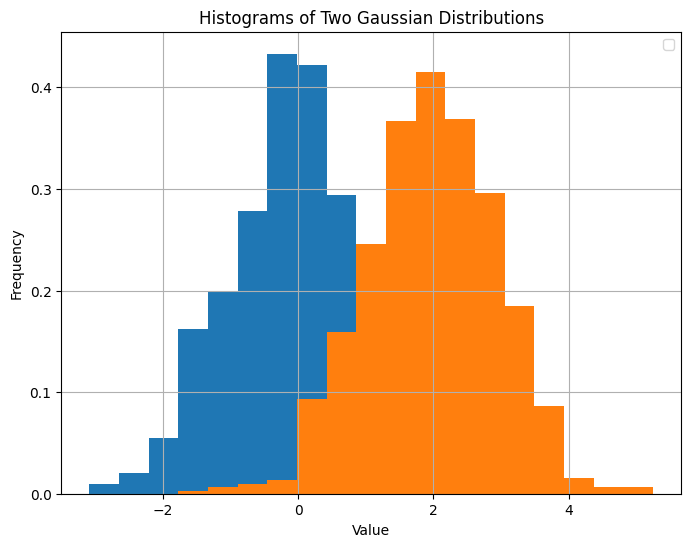

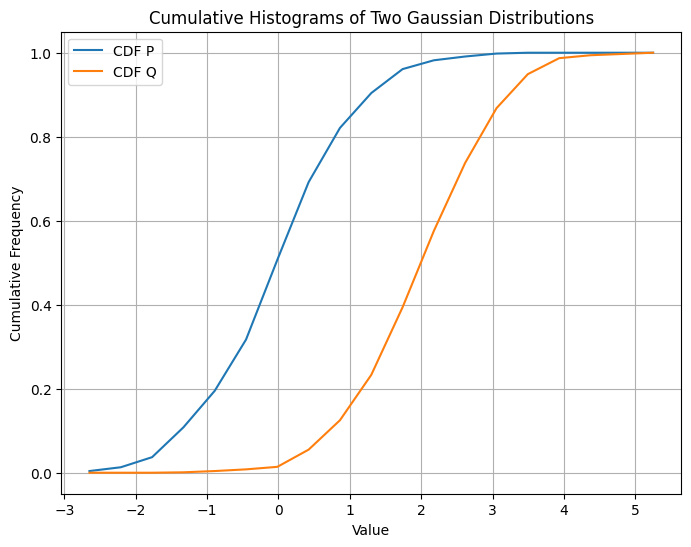

In [24]:
# for continuous distributions
import numpy as np
import matplotlib.pyplot as plt

# Parameters of two normal distributions
mean_p, std_p = 0, 1
mean_q, std_q = 2, 1

# Generate random samples from the two normal distributions
samples_p = np.random.normal(mean_p, std_p, size=1000)
samples_q = np.random.normal(mean_q, std_q, size=1000)

# Determine the bin edges for the histograms
bin_edges = np.linspace(min(samples_p.min(), samples_q.min()), max(samples_p.max(), samples_q.max()), num=20)

mean_points = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(bin_edges) - 1)]

# Create histograms of the two distributions with the same binning
hist_p, _ = np.histogram(samples_p, bins=bin_edges, density=True)
hist_q, _ = np.histogram(samples_q, bins=bin_edges, density=True)

delta_bin=np.diff(bin_edges)[0]
# Compute cumulative histograms
cumulative_hist_p = np.cumsum(hist_p)*delta_bin
cumulative_hist_q = np.cumsum(hist_q)*delta_bin

# Plot the histograms
plt.figure(figsize=(8, 6))
plt.hist(samples_p, bins=bin_edges, density=True)
plt.hist(samples_q, bins=bin_edges, density=True)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histograms of Two Gaussian Distributions')
plt.legend()
plt.grid(True)
plt.show()

# Plot the cumulative histograms
plt.figure(figsize=(8, 6))
plt.plot(bin_edges[1:], cumulative_hist_p, label='CDF P')
plt.plot(bin_edges[1:], cumulative_hist_q, label='CDF Q')
plt.xlabel('Value')
plt.ylabel('Cumulative Frequency')
plt.title('Cumulative Histograms of Two Gaussian Distributions')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
from scipy.stats import wasserstein_distance
# Compute the 1-Wasserstein distance using bins mean points and normalized histogram values
wasserstein_dist_from_prob_density = wasserstein_distance(mean_points, mean_points, hist_p, hist_q)

print("1-Wasserstein Distance between the histograms:", wasserstein_dist_from_prob_density)

1-Wasserstein Distance between the histograms: 2.0124487200063674


In [26]:
from scipy.stats import wasserstein_distance_nd
# Compute the 1-Wasserstein distance using discrete samples
wasserstein_dist_from_sample = wasserstein_distance_nd(samples_p, samples_q)
wasserstein_dist_from_sample
print("1-Wasserstein Distance between samples:", wasserstein_dist_from_sample)

1-Wasserstein Distance between samples: 2.002934497612951


In [27]:
# Compute the 1-Wasserstein distance using the analitic definition of wasserstein distance in 1d
# w is integral of the absolute dfference between the cumulate density funtions (CDF) of the two distributions.
# consider using the rectangle approximation of the CDF provided by the cumulative histograms computed above.

wasserstein_from_cumulative_histograms=np.sum(np.abs(cumulative_hist_p-cumulative_hist_q))*delta_bin
print("1-Wasserstein Distance from integral approximation:", wasserstein_from_cumulative_histograms)

1-Wasserstein Distance from integral approximation: 2.01244872000637


In [28]:
# try to compute the same distance using KL divergence
delta_bin*np.sum(rel_entr(hist_p, hist_q)), delta_bin*np.sum(rel_entr(hist_q,hist_p))

(np.float64(inf), np.float64(inf))

# Excercise:
define a function that is able to compute the similarity of records in a table having arbitrary attribute types (nominal,binary,ordinal,numeric)

In [29]:

from scipy.spatial.distance import euclidean
from joblib import Parallel, delayed

def cosine_distance_TF_IDF_BOW(tfidf_matrix, i, j):
    """
    tfidf_matrix : scipy sparse matrix of shape (n_samples, n_features)
        TF-IDF representation for one text column.
    i, j : int
        Row indices.
    """
    sim = cosine_similarity(tfidf_matrix[i], tfidf_matrix[j])[0, 0]
    return 1.0 - sim


def parallel_dissimilarity_matrix(df, dict_types):
    """
    Compute a mixed-type pairwise dissimilarity matrix.

    Supported types
    ---------------
    'NO' : Nominal
    'NU' : Numerical
    'SB' : Symmetric Binary
    'AB' : Asymmetric Binary
    'TX' : Text/String using TF-IDF (single-word bag of words) + cosine dissimilarity

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe with mixed attribute types.
    dict_types : dict
        Dictionary mapping column names to type codes.

    Returns
    -------
    pandas.DataFrame
        Symmetric dissimilarity matrix.
    """

    num_records = df.shape[0]
    dissimilarity_matrix = np.zeros((num_records, num_records), dtype=float)

    distance_functions = {
        'NO': nominal_distance,
        'NU': euclidean,
        'SB': symmetric_binary_distance,
        'AB': jaccard,
        'TX': cosine_distance_TF_IDF_BOW,   # handled separately (need to create overall vocabulary)
    }

    # Pre-extract raw data for non-text columns
    data = {col: df[col].values for col in dict_types.keys()}

    # --------------------------------------------------
    # Precompute TF-IDF matrices for text columns
    # --------------------------------------------------
    text_columns = [col for col, coltype in dict_types.items() if coltype == 'TX']
    tfidf_data = {}

    for col in text_columns:
        # Replace NaN with empty string for vectorization
        corpus = df[col].fillna("").astype(str).values

        vectorizer = TfidfVectorizer(
            lowercase=True,
            analyzer="word",
            ngram_range=(1, 1)   # single words only
        )
        tfidf_matrix = vectorizer.fit_transform(corpus)

        tfidf_data[col] = {
            "vectorizer": vectorizer,
            "matrix": tfidf_matrix
        }

    def compute_dissimilarity(i, j):
        dissimilarity = 0.0
        num_valid_elements = 0

        for col, coltype in dict_types.items():
            val_i = data[col][i]
            val_j = data[col][j]

            if coltype == 'TX':
                # For text, consider missing only if original value is NaN
                if pd.notna(val_i) and pd.notna(val_j):
                    tfidf_matrix = tfidf_data[col]["matrix"]
                    distance_func = distance_functions[coltype]
                    dissimilarity += distance_func(tfidf_matrix, i, j)
                    num_valid_elements += 1
            else:
                # Non-text columns
                if pd.notna(val_i) and pd.notna(val_j):
                    distance_func = distance_functions[coltype]
                    dissimilarity += distance_func([val_i], [val_j])

                    # For AB, ignore double-zero matches in denominator
                    if not (coltype == 'AB' and (val_i == 0 and val_j == 0)):
                        num_valid_elements += 1

            if coltype == 'TX':
                # For text, consider missing only if original value is NaN
                if pd.notna(val_i) and pd.notna(val_j):
                    tfidf_matrix = tfidf_data[col]["matrix"]
                    distance_func = distance_functions[coltype]
                    dissimilarity += distance_func(tfidf_matrix, i, j)
                    num_valid_elements += 1
            else:
                # Non-text columns
                if pd.notna(val_i) and pd.notna(val_j):
                    distance_func = distance_functions[coltype]
                    dissimilarity += distance_func([val_i], [val_j])

                    # For AB, ignore double-zero matches in denominator
                    if not (coltype == 'AB' and (val_i == 0 and val_j == 0)):
                        num_valid_elements += 1

        if num_valid_elements > 0:
            return dissimilarity / num_valid_elements
        return np.nan

    upper_tri_pairs = [
        (i, j)
        for i in range(num_records - 1)
        for j in range(i + 1, num_records)
    ]

    results = Parallel(n_jobs=-1)(
        delayed(compute_dissimilarity)(i, j) for (i, j) in upper_tri_pairs
    )

    for (i, j), val in zip(upper_tri_pairs, results):
        dissimilarity_matrix[i, j] = val
        dissimilarity_matrix[j, i] = val

    np.fill_diagonal(dissimilarity_matrix, 0.0)

    return pd.DataFrame(dissimilarity_matrix, index=df.index, columns=df.index)


## Load Titanic dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/path') ###change path


In [30]:
import pandas as pd
df=pd.read_csv('train.csv') ##change path
# Define bins and labels for age groups
bins = [0, 14, 24, 54, float('inf')]
labels = ['Children', 'Young', 'Middle', 'Seniors']

# Add a new column 'Age_Group' containing ordinal categories
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)


features_to_consider=['Survived',	'Pclass', 'Sex',	'Age_Group',	'SibSp',	'Parch', 'Fare', 'Embarked']
df=df[features_to_consider]
df.head(20)

,Survived,Pclass,Sex,Age_Group,SibSp,Parch,Fare,Embarked
0,0,3,male,Young,1,0,7.2500,S
1,1,1,female,Middle,1,0,71.2833,C
2,1,3,female,Middle,0,0,7.9250,S
3,1,1,female,Middle,1,0,53.1000,S
4,0,3,male,Middle,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,Seniors,0,0,51.8625,S
7,0,3,male,Children,3,1,21.0750,S
8,1,3,female,Middle,0,2,11.1333,S
9,1,2,female,Young,1,0,30.0708,C


In [ ]:
dict_types = {
    'Survived': 'SB',
    'Pclass': 'NO',
    'Sex': 'NO',
    'Age_Group': 'NO',
    'SibSp': 'NU',
    'Parch': 'NU',
    'Fare': 'NU',
    'Embarked': 'NO'
}

In [ ]:

#let's try to compute the similarity between first two records
sub_df = df.iloc[[0, 1]]  
dissimilarity_matrix = parallel_dissimilarity_matrix(sub_df, dict_types)
print(dissimilarity_matrix)

#Sinche this is a dissimilarity matrix, the diagonal shows 0, and having a high value
# as 8 on the extra-diagonal values, means that the two records are dissimilar


          0         1
0  0.000000  8.629162
1  8.629162  0.000000


In [ ]:
#Now let's do the same thing for the first 100 records.
sub_df = df.iloc[:100]
dissimilarity_matrix = parallel_dissimilarity_matrix(sub_df, dict_types)
print(dissimilarity_matrix)

#Having a 100x100 matrix is a bit hard to read,
#but if we look at the first records and compare it to the fifth one (the one under 4 label)
# we can see that the dissimilarity is 0.35 which is pretty low, meaning that the two are similar.

          0         1         2         3         4         5         6   \
0   0.000000  8.629162  0.584375  6.231250  0.350000  0.458329  5.951562   
1   8.629162  0.000000  8.294787  2.397912  8.529162  9.689286  3.052600   
2   0.584375  8.294787  0.000000  5.896875  0.265625  0.504757  5.992188   
3   6.231250  2.397912  5.896875  0.000000  6.131250  7.091671  0.654688   
4   0.350000  8.529162  0.265625  6.131250  0.000000  0.201186  5.726562   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.257143  9.747614  0.303571  7.007143  0.000000  0.201186  6.401786   
96  3.925525  5.078637  3.966150  2.930725  3.700525  4.027986  2.276037   
97  7.638537  1.490625  7.554163  1.907287  7.538538  8.414286  1.936975   
98  2.718750  6.535412  2.134375  4.137500  2.368750  2.791671  4.232812   
99  2.593750  6.160412  2.759375  3.762500  2.493750  2.934529  3.607812   

          7         8         9   ...        90        91        92        93  \
0   2.

In [ ]:
#In order to display the 10th closest records to first and second one we can look at
# dissimilarity matrix columns and sort them.

#I m cutting the first row since its the first record itself.
dissimilarity_matrix.iloc[1:,0].sort_values().head(10)
dissimilarity_matrix.iloc[1:,1].sort_values().head(10)


51    0.193750
91    0.200525
37    0.225000
12    0.225000
76    0.235114
29    0.235114
67    0.238538
94    0.250000
60    0.252600
87    0.257143
45    0.257143
Name: 0, dtype: float64

### Excercise
* prepare data to compute similarity between different records
* compute the dissimilarity matrix considering the first 100 records
* find the 10 records more similar to the first two passengers (index=0, index=1)
* compute the distance between the distributions of ticket fares in the Male and Female population. 